In [ ]:
pip install numpy scipy fooof

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.5/130.5 kB 3.9 MB/s eta 0:00:00


In [ ]:
! pip install mne

In [ ]:
#FROM EDF TO .mat
file = "Terracciano 1B.edf"
data = mne.io.read_raw_edf(file)
raw_data = data.get_data()

In [ ]:
#FROM EDF TO .mat
scipy.io.savemat('Terracciano 1B.mat', {'raw_data':raw_data})

In [ ]:
from scipy.io import loadmat
mat = loadmat("Romano_oa_posttES_pulito.mat");


In [ ]:
eeg_data=mat["X"];

/tmp/ipython-input-2854373610.py:3: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinf

Theta peak frequency: 5.65 Hz


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

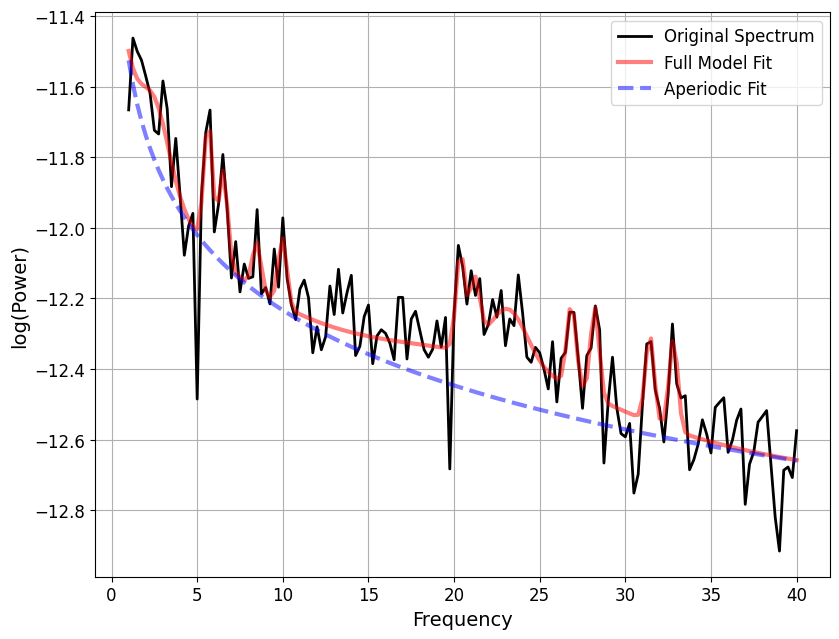

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import numpy as np
from scipy.signal import welch
from fooof import FOOOF

# ======================
# PARAMETRI
# ======================
fs = 250                       # Hz
segment_length_sec = 4         # secondi
segment_samples = fs * segment_length_sec
channel_idx = 4                # canale 5 (0-based indexing)
theta_band = (4.0, 8.0)        # Hz
fallback_freq = 6.0            # Hz

#eeg data

signal = eeg_data[channel_idx, :]

# ======================
# SEGMENTAZIONE (4 s)
# ======================
n_segments = signal.shape[0] // segment_samples
segments = signal[:n_segments * segment_samples]
segments = segments.reshape(n_segments, segment_samples)

# ======================
# WELCH PSD
# ======================
# Risoluzione in frequenza = fs / nperseg = 0.25 Hz
nperseg = int(fs / 0.25)

psd_list = []

for seg in segments:
    freqs, psd = welch(
        seg,
        fs=fs,
        window='hamming',
        nperseg=nperseg,
        noverlap=0,
        detrend='constant',
        scaling='density'
    )
    psd_list.append(psd)

# PSD media sui segmenti
mean_psd = np.mean(psd_list, axis=0)

# ======================
# FOOOF
# ======================
#fm = FOOOF(
#    peak_width_limits=(1, 6),
#    max_n_peaks=6,
#    min_peak_height=0.1,
#    peak_threshold=2.0,
#    aperiodic_mode='fixed'
#)

fm = FOOOF()

fm.fit(freqs, mean_psd, freq_range=[1, 40])
fm.plot()

# ======================
# ESTRAZIONE THETA PEAK
# ======================
theta_peaks = []

for peak in fm.peak_params_:
    cf, amp, bw = peak
    if theta_band[0] <= cf <= theta_band[1]:
        theta_peaks.append((cf, amp))

if theta_peaks:
    # scegli il picco theta con ampiezza massima
    theta_peak_freq = max(theta_peaks, key=lambda x: x[1])[0]
else:
    theta_peak_freq = fallback_freq

# ======================
# OUTPUT
# ======================
print(f"Theta peak frequency: {theta_peak_freq:.2f} Hz")

In [ ]:
print(fm.peak_params_)

[[ 5.95569255  0.61255114  2.00001786]
 [ 8.61346014  1.74214538  2.03099001]
 [10.93865994  1.05984594  5.11983115]
 [18.49836923  0.72758812 10.01386307]
 [23.40756829  0.60394367  0.95912527]
 [26.28221034  0.32627659  0.5       ]]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag